In [94]:
from unet import *
from losses import *
from baseline_tree import *

import keras
import tensorflow as tf 

In [3]:
model3, train_data, gt_train_labels, validation_data, gt_validation_labels = load_model_and_data()

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - f1_metric: 0.8152 - loss: 0.1855 - val_f1_metric: 0.8196 - val_loss: 0.1825
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - f1_metric: 0.8166 - loss: 0.1845 - val_f1_metric: 0.8210 - val_loss: 0.1811
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 87s 8s/step - f1_metric: 0.8168 - loss: 0.1841 - val_f1_metric: 0.8218 - val_loss: 0.1798
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - f1_metric: 0.8167 - loss: 0.1841 - val_f1_metric: 0.8227 - val_loss: 0.1790
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - f1_metric: 0.8157 - loss: 0.1850 - val_f1_metric: 0.8230 - val_loss: 0.1784


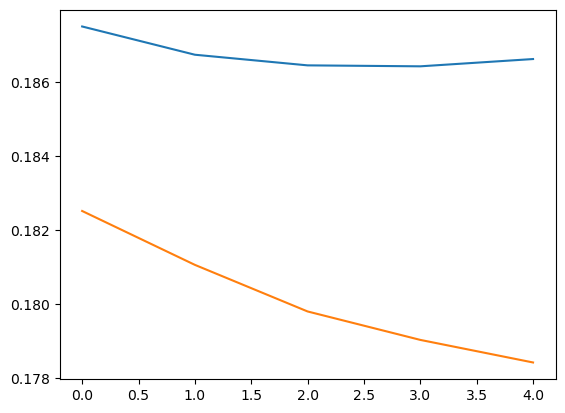

In [28]:
# Compile the model
epochs = 5
batch_size = 128

class DebugCallback(tf.keras.callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate
        print(f"Batch {batch}: Loss = {logs['loss']}, Learning Rate = {lr.numpy()}")


lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0001,
    decay_steps= len(train_data)//(batch_size*10),
    decay_rate=0.9)

# Defining optimizer
opt = keras.optimizers.Adam(learning_rate=lr_schedule)
model3.compile(
    optimizer=opt,
    loss=soft_f1_loss,        # OR loss=soft_f1_loss
    metrics=[f1_metric],
)

# Training the model
history = model3.fit(
train_data, gt_train_labels,
epochs=epochs,
batch_size=batch_size,
validation_data=(validation_data, gt_validation_labels),
verbose=1,
)

# Plot the loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')

In [50]:
# Compute the number of True positives, False positives and False negatives for the validation set
gt_validation_predictions = model3.predict(validation_data)
gt_train_predictions = model3.predict(train_data)

tp = tf.reduce_sum(gt_validation_labels * gt_validation_predictions)
fp = tf.reduce_sum((1 - gt_validation_labels) * gt_validation_predictions)
fn = tf.reduce_sum(gt_validation_labels * (1 - gt_validation_predictions))

precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)
f1 = 2 * precision * recall / (precision + recall + 1e-7)

metrics = [precision, recall, f1, tp, fp, fn]
print(f"Precision: {precision}, Recall: {recall}, F1: {f1}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step
Precision: 0.810990035533905, Recall: 0.8457145094871521, F1: 0.82798832654953


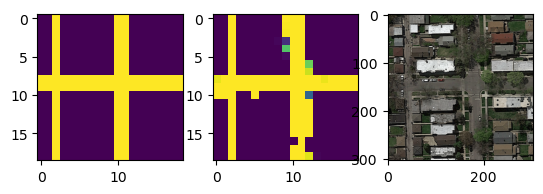

In [29]:
i = 14
plt.subplot(1, 3, 1)
plt.imshow(gt_validation_labels[i])
plt.subplot(1, 3, 2)
plt.imshow(gt_validation_predictions[i].reshape(19, 19))
plt.subplot(1, 3, 3)
plt.imshow(validation_data[i])

## Denoising

In [30]:
#Denoise with an otsu filter and compute the new metrics
from skimage.filters import threshold_otsu
from skimage import img_as_ubyte

def denoise_image(image):
    thresh = threshold_otsu(image)
    binary = image > thresh
    return binary

denoised_predictions = np.array([denoise_image(img.reshape(19, 19)).reshape(19, 19, 1) for img in gt_validation_predictions])

tp = tf.reduce_sum(gt_validation_labels * denoised_predictions)
fp = tf.reduce_sum((1 - gt_validation_labels) * denoised_predictions)
fn = tf.reduce_sum(gt_validation_labels * (1 - denoised_predictions))

precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)

f1 = 2 * precision * recall / (precision + recall + 1e-7)
print(f"Precision: {precision}, Recall: {recall}, F1: {f1}")

Precision: 0.8131333589553833, Recall: 0.8401179313659668, F1: 0.82640540599823


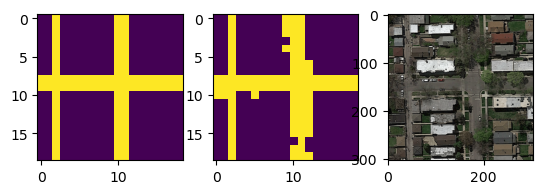

In [32]:
i = 14
plt.subplot(1, 3, 1)
plt.imshow(gt_validation_labels[i])
plt.subplot(1, 3, 2)
plt.imshow(denoised_predictions[i].reshape(19, 19))
plt.subplot(1, 3, 3)
plt.imshow(validation_data[i])

In [64]:
train_data.shape, 19*19, gt_train_labels.shape

((1380, 304, 304, 3), 361, TensorShape([1380, 19, 19, 1]))

In [97]:
# Cut th etrain_data into 16x16 patches
def cut_patches(data, gt, predictions, patch_size):
    data_patches = []
    gt_patches = []
    predictions_patches = []
    for img in data:
        for i in range(0, img.shape[0], patch_size):
            for j in range(0, img.shape[1], patch_size):
                data_patches.append(img[i:i+patch_size, j:j+patch_size])
                
    for i in range(0, gt.shape[0]):
        for j in range(0, gt.shape[1]):
            for k in range(0, gt.shape[2]):
                gt_patches.append(gt[i, j, k])
                predictions_patches.append(predictions[i, j, k][0])
    return np.array(data_patches), np.array(gt_patches), predictions_patches

train_data_patches, gt_train_patches, predictions_patches = cut_patches(train_data[0:100], gt_train_labels[0:100], gt_train_predictions[0:100], 16)
validation_data_patches, gt_validation_patches, validation_predictions_patches = cut_patches(validation_data, gt_validation_labels, denoised_predictions, 16)
train_data_patches.shape, gt_train_patches.shape

((36100, 16, 16, 3), (36100, 1))

In [112]:
def denoise_labels(train_data_patches, gt_train_patches, predictions_patches):
    # Fetch the original image surroundings and extract it into a numpy array. The surroundings are the 3x3 patches around the 16x16 patches
    surroundings = []
    for i in range(0, 100):
        for j in range(0, 19):
            for k in range(0, 19):
                surroundings.append(train_data[0][j:j+3, k:k+3])

    c0 = 0  # bgrd
    c1 = 0  # road
    for i in range(len(gt_train_patches)):  # Iterate over each patch
        if gt_train_patches[i] == 1:     
            c0 = c0 + 1
        else:
            c1 = c1 + 1
    print("Number of data points per class: c0 = " + str(c0) + " c1 = " + str(c1))
    
    print("Balancing training data...")
    min_c = min(c0, c1)
    idx0 = [i for i, j in enumerate(gt_train_patches) if j == 0]     # Get the indices of the patches that are background
    idx1 = [i for i, j in enumerate(gt_train_patches) if j == 1]     # Get the indices of the patches that are road
    new_indices = idx0[0:min_c] + idx1[0:min_c]
    
    print(len(new_indices))
    print(train_data_patches.shape)
    
    data_patches = train_data_patches[new_indices, :, :, :]
    labels_patches = gt_train_patches[new_indices]
    filtered_predictions_patches = []
    filtered_surroundings = []
    for i in new_indices:
        filtered_surroundings.append(surroundings[i])
        filtered_predictions_patches.append(predictions_patches[i])
    surroundings = filtered_surroundings
    predictions_patches = filtered_predictions_patches
    
    c0 = 0
    c1 = 0
    for i in range(len(labels_patches)):
        if labels_patches[i][0] == 1:
            c0 = c0 + 1
        else:
            c1 = c1 + 1
    print("Number of data points per class: c0 = " + str(c0) + " c1 = " + str(c1))
    
    similarity, is_tree, is_grey, is_surr_light, is_patch_light = compute_features(data_patches, surroundings)
    data_svm = np.array([similarity, is_tree, is_grey, is_surr_light, is_patch_light, predictions_patches]).T
    labels_svm = np.array([1 if label == 1 else 0 for label in labels_patches])

    # Shuffle the data
    indices = np.random.permutation(data_svm.shape[0])
    data_svm = data_svm[indices]
    labels_svm = labels_svm[indices]

    print("Beggining training")
    accuracy, f1, clf = train_classifier(data_svm, labels_svm)
    print("Accuracy: " + str(accuracy))
    print("F1 score: " + str(f1))
    
    return clf

clf = denoise_labels(train_data_patches, gt_train_patches, predictions_patches)

Number of data points per class: c0 = 9333 c1 = 26767
Balancing training data...
18666
(36100, 16, 16, 3)
Number of data points per class: c0 = 9333 c1 = 9333
Beggining training
Accuracy: 0.8976968398500268
F1 score: 0.8944168048645661


In [ ]:
# Use clf to denoise the predictions on the validation set
def denoise_predictions(clf, validation_data, gt_validation_predictions):
    surroundings = []
    for i in range(0, len(validation_data)):
        for j in range(0, 19):
            for k in range(0, 19):
                surroundings.append(validation_data[i][j:j+3, k:k+3])
    similarity, is_tree, is_grey, is_surr_light, is_patch_light = compute_features(validation_data, surroundings)
    predictions = np.array([similarity, is_tree, is_grey, is_surr_light, is_patch_light, gt_validation_predictions]).T
    denoised_predictions = clf.predict(predictions)
    return denoised_predictions

denoised_predictions = denoise_predictions(clf, validation_data_patches[0:100], validation_predictions_patches[0:100])

## Predictions on the test data

In [ ]:
# Extract the test data
TEST_SIZE = 50  # Size of the test data   
test_data = extract_test_data("test_set_images/", TEST_SIZE)

first_test_data_patches, second_test_data_patches, third_test_data_patches, fourth_test_data_patches = crop_test_data(test_data)

In [ ]:
# Predict for the test data
first_gt_test_predicted_labels = model2.predict(first_test_data_patches)
second_gt_test_predicted_labels = model2.predict(second_test_data_patches)
third_gt_test_predicted_labels = model2.predict(third_test_data_patches)
fourth_gt_test_predicted_labels = model2.predict(fourth_test_data_patches)

# Combine the predictions
gt_test_predicted_labels = np.zeros((TEST_SIZE, 38, 38))

for i in range(TEST_SIZE):
    gt_test_predicted_labels[i][:19, :19] = first_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][:19, 19:] = second_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, :19] = third_gt_test_predicted_labels[i].reshape(19, 19)
    gt_test_predicted_labels[i][19:, 19:] = fourth_gt_test_predicted_labels[i].reshape(19, 19)
    
gt_test_predicted_labels.shape

In [ ]:
# Display the first image and the label
i = 5
image = test_data[i]
prediction = gt_test_predicted_labels[i]
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(prediction)

In [ ]:
test_data_patches = cut_patches(test_data, 16)

# Denoise the predictions


# Extract the patches and surroundings from the test data
test_surroundings = extract_test_surroundings("test_set_images/", TEST_SIZE)
test_features = compute_features(test_data, test_surroundings)
test_predictions = gt_test_predicted_labels.flatten()

# Predict the labels of the test data
test_data_svm = np.array([test_features[0], test_features[1], test_features[2], test_features[3], test_features[4], test_predictions]).T
test_labels = clf.predict(test_data_svm)

In [ ]:
# Save the model

In [ ]:
# Denoise the predictions
denoised_test_predicted_labels = denoise(gt_test_predicted_labels)

In [ ]:
# Create csv submission
filename = "submission_single_denoised_Unet2.csv"
create_csv_submission(filename, denoised_gt_test_predicted_labels)

In [ ]:
# Reconstruct the images from submission
im = reconstruct_from_labels(4)
plt.subplot(1, 2, 1)
plt.imshow(im)
plt.subplot(1, 2, 2)
plt.imshow(test_data[3])